# 09 — Zero-Shot NLI Validation of Anchor Posts

Independent validation of anchor-post quality using `facebook/bart-large-mnli`.
Tests whether posts identified by SVM + keyword filter genuinely express
negative admissions outcomes — without relying on the same classifiers used
to identify them.

**Inputs:**
- `data/processed/{SUBREDDIT}/anchor_posts.parquet` (all 3 subreddits by default)

**Outputs:**
- `data/processed/nli_anchor_validation.parquet` — cached inference results
- `figures/fig_nli_validation_scores.png` — score distributions
- `figures/fig_nli_kappa_confusion.png` — confusion matrix (requires posts_clean.jsonl)

**What is reported:**
1. % of anchor posts where BART's top label is a negative-outcome label vs general discussion
2. Distribution of BART entailment scores for the top negative label across all anchor posts
3. 10 agree examples (high SVM + BART confirms negative) and 10 disagree examples
4. Cohen's Kappa between BART and SVM anchor classification (requires posts_clean.jsonl for non-anchor sample)

**Estimated inference time:** ~5–15 min on Apple MPS, ~30–60 min on CPU for ~2,000 posts.
Inference is cached to parquet — subsequent runs load instantly.

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                        NLI CONFIG                           ║
# ╚══════════════════════════════════════════════════════════════╝

# Which subreddits to validate. All three are run by default.
SUBREDDITS = ['gradadmissions', 'mscs', 'mba']

CANDIDATE_LABELS = [
    'negative admissions outcome',
    'rejection or funding loss',
    'giving up on graduate school',
    'general admissions discussion',
]
NEGATIVE_LABELS = {l for l in CANDIDATE_LABELS if l != 'general admissions discussion'}

NLI_MODEL  = 'facebook/bart-large-mnli'
BATCH_SIZE = 8       # reduce to 4 if OOM on CPU
MAX_CHARS  = 2000    # post text sent to BART; longer posts are truncated here

# Sample size of NON-anchor posts drawn per subreddit for Cohen's Kappa.
# Requires posts_clean.jsonl (not in git; generated by NB01).
KAPPA_NON_ANCHOR_SAMPLE = 300
KAPPA_SEED = 42

In [ ]:
import json
import warnings
import importlib
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

ROOT    = Path('..').resolve()
DATA    = ROOT / 'data' / 'processed'
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

NLI_RESULTS_PATH = DATA / 'nli_anchor_validation.parquet'

print('Repo root        :', ROOT)
print('NLI results cache:', NLI_RESULTS_PATH)

In [3]:
# ── Install heavyweight deps if missing ────────────────────────────────────
def _ensure(pkg, import_name=None):
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        print(f'Installing {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
    else:
        print(f'{name} already available')

_ensure('transformers')
_ensure('torch')
_ensure('tqdm')

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw): return it  # silent fallback

print('Dependencies OK')

transformers already available
torch already available
tqdm already available
Dependencies OK


In [ ]:
# ── Load anchor posts from all subreddits ──────────────────────────────────
frames = []
for sub in SUBREDDITS:
    path = DATA / sub / 'anchor_posts.parquet'
    df = pd.read_parquet(path)
    df['subreddit'] = sub
    frames.append(df)
    print(f'r/{sub}: {len(df)} anchor posts')

anchors = pd.concat(frames, ignore_index=True)
anchors['cycle'] = anchors['cycle'].astype(int)

print(f'\nTotal anchor posts: {len(anchors)}')
anchors.groupby('subreddit')[['mean_mh_score']].agg(['count', 'mean', 'std']).round(3)

In [5]:
# ── Device detection + load NLI pipeline ───────────────────────────────────
# Skip this cell if NLI_RESULTS_PATH already exists and you only need analysis.

import torch
from transformers import pipeline as hf_pipeline

if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

n_posts = len(anchors)
est_lo  = int(n_posts * 0.5)
est_hi  = int(n_posts * 2.0)
print(f'Device            : {device}')
print(f'Posts to score    : {n_posts}')
print(f'Est. inference    : {est_lo}–{est_hi}s on {device}')
print(f'Cache exists      : {NLI_RESULTS_PATH.exists()}')
print()
print('Loading facebook/bart-large-mnli ...')
nli_pipe = hf_pipeline(
    'zero-shot-classification',
    model=NLI_MODEL,
    device=device,
)
print('Pipeline loaded.')

Device            : mps
Posts to score    : 1826
Est. inference    : 913–3652s on mps
Cache exists      : True

Loading facebook/bart-large-mnli ...


Device set to use mps


Pipeline loaded.


In [6]:
# ── Run inference  OR  load from cache ─────────────────────────────────────

def parse_result(r):
    """Extract top label, top score, best negative label + score, binary flag."""
    label_score    = dict(zip(r['labels'], r['scores']))
    top_label      = r['labels'][0]
    top_score      = r['scores'][0]
    top_neg_label  = max(NEGATIVE_LABELS, key=lambda l: label_score.get(l, 0.0))
    top_neg_score  = label_score[top_neg_label]
    bart_is_neg    = top_label in NEGATIVE_LABELS
    return top_label, top_score, top_neg_label, top_neg_score, bart_is_neg


if NLI_RESULTS_PATH.exists():
    anchors = pd.read_parquet(NLI_RESULTS_PATH)
    print(f'Loaded {len(anchors)} rows from cache: {NLI_RESULTS_PATH.name}')

else:
    if 'nli_pipe' not in globals():
        raise RuntimeError('Run the pipeline-loading cell (cell 6) first.')

    texts = anchors['clean_text'].fillna('').str[:MAX_CHARS].tolist()

    raw_results = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc='BART inference'):
        batch = texts[i : i + BATCH_SIZE]
        out = nli_pipe(batch, candidate_labels=CANDIDATE_LABELS, multi_label=False)
        if isinstance(out, dict):   # single-item batch returns dict, not list
            out = [out]
        raw_results.extend(out)

    parsed = [parse_result(r) for r in raw_results]
    anchors[['bart_top_label', 'bart_top_score',
             'bart_top_neg_label', 'bart_top_neg_score',
             'bart_is_negative']] = parsed

    anchors.to_parquet(NLI_RESULTS_PATH, index=False)
    print(f'Inference done. Saved to {NLI_RESULTS_PATH.name}')

# Normalise dtype — parquet round-trips booleans as int8 on some engines
anchors['bart_is_negative'] = anchors['bart_is_negative'].astype(bool)

print()
anchors[['subreddit', 'cycle', 'mean_mh_score',
         'bart_top_label', 'bart_top_score', 'bart_is_negative']].head()

Loaded 1826 rows from cache: nli_anchor_validation.parquet



,subreddit,cycle,mean_mh_score,bart_top_label,bart_top_score,bart_is_negative
0,gradadmissions,2,0.562860,negative admissions outcome,0.704654,True
1,gradadmissions,2,0.482700,rejection or funding loss,0.385488,True
2,gradadmissions,2,0.443583,negative admissions outcome,0.546608,True
3,gradadmissions,2,0.443547,general admissions discussion,0.424659,False
4,gradadmissions,2,0.563594,negative admissions outcome,0.882113,True


In [7]:
# ── (1) Summary statistics ─────────────────────────────────────────────────

total = len(anchors)
n_neg = anchors['bart_is_negative'].sum()

print('=' * 60)
print('OVERALL')
print('=' * 60)
print(f'Anchor posts confirmed negative by BART : {n_neg}/{total}  ({100*n_neg/total:.1f}%)')
print(f'Labeled general admissions discussion   : {total-n_neg}/{total}  ({100*(total-n_neg)/total:.1f}%)')

print()
print('--- Per-subreddit confirmation rate ---')
for sub, grp in anchors.groupby('subreddit'):
    n = len(grp)
    nn = grp['bart_is_negative'].sum()
    print(f'  r/{sub:<18s}: {nn}/{n}  ({100*nn/n:.1f}%)')

print()
print('--- Top-label distribution (all subreddits) ---')
print(anchors['bart_top_label'].value_counts().to_string())

print()
print('--- Per-subreddit × top-label breakdown ---')
cross = anchors.groupby(['subreddit', 'bart_top_label']).size().unstack(fill_value=0)
print(cross.to_string())

print()
print('--- Mean BART top-negative-label score by subreddit ---')
print(anchors.groupby('subreddit')['bart_top_neg_score']
      .agg(['mean', 'median', 'std']).round(3).to_string())

OVERALL
Anchor posts confirmed negative by BART : 1425/1826  (78.0%)
Labeled general admissions discussion   : 401/1826  (22.0%)

--- Per-subreddit confirmation rate ---
  r/gradadmissions    : 990/1255  (78.9%)
  r/mba               : 369/471  (78.3%)
  r/mscs              : 66/100  (66.0%)

--- Top-label distribution (all subreddits) ---
bart_top_label
negative admissions outcome      1268
general admissions discussion     401
rejection or funding loss         139
giving up on graduate school       18

--- Per-subreddit × top-label breakdown ---
bart_top_label  general admissions discussion  giving up on graduate school  negative admissions outcome  rejection or funding loss
subreddit                                                                                                                          
gradadmissions                            265                            13                          881                         96
mba                                       102     

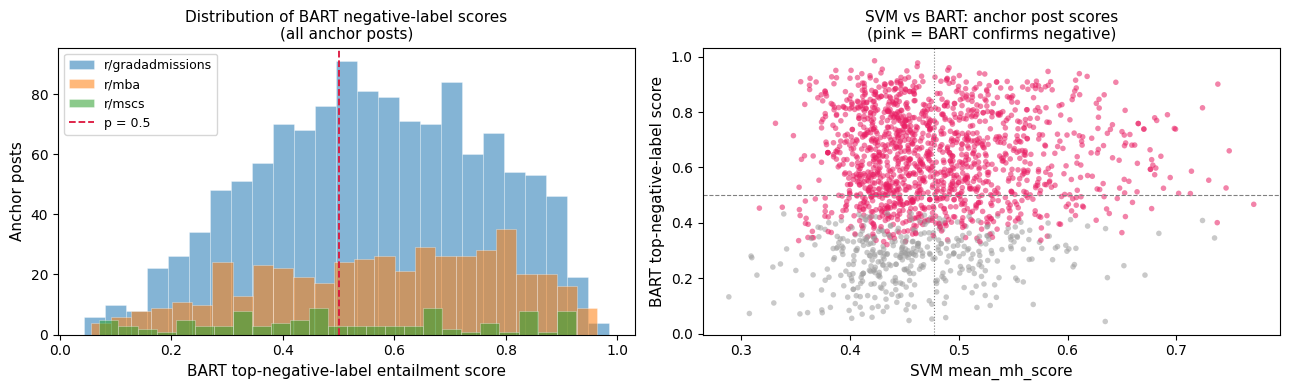

Saved: fig_nli_validation_scores.png


In [8]:
# ── (2) Score distribution plots ───────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram of top-negative-label score across all anchor posts
ax = axes[0]
for sub, grp in anchors.groupby('subreddit'):
    ax.hist(grp['bart_top_neg_score'], bins=25, alpha=0.55, label=f'r/{sub}',
            edgecolor='white', linewidth=0.4)
ax.axvline(0.5, color='crimson', linestyle='--', linewidth=1.3, label='p = 0.5')
ax.set_xlabel('BART top-negative-label entailment score', fontsize=11)
ax.set_ylabel('Anchor posts', fontsize=11)
ax.set_title('Distribution of BART negative-label scores\n(all anchor posts)', fontsize=11)
ax.legend(fontsize=9)

# Right: SVM mean_mh_score vs BART top_neg_score, coloured by BART verdict
ax = axes[1]
colours = anchors['bart_is_negative'].map({True: '#E91E63', False: '#9E9E9E'})
ax.scatter(anchors['mean_mh_score'], anchors['bart_top_neg_score'],
           c=colours, alpha=0.55, s=16, linewidths=0)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.axvline(anchors['mean_mh_score'].mean(), color='grey', linestyle=':', linewidth=0.8)
ax.set_xlabel('SVM mean_mh_score', fontsize=11)
ax.set_ylabel('BART top-negative-label score', fontsize=11)
ax.set_title('SVM vs BART: anchor post scores\n(pink = BART confirms negative)', fontsize=11)

plt.tight_layout()
out_path = FIG_DIR / 'fig_nli_validation_scores.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path.name}')

In [9]:
# ── (3) Agree / Disagree examples ─────────────────────────────────────────
# Agree   : high SVM score AND BART top label is a negative-outcome label
# Disagree: high SVM score AND BART top label is 'general admissions discussion'

pd.set_option('display.max_colwidth', 500)

PRINT_CHARS = 600
N_EXAMPLES  = 10

agree = (
    anchors[anchors['bart_is_negative']]
    .nlargest(N_EXAMPLES * 3, 'mean_mh_score')
    .head(N_EXAMPLES)
    .reset_index(drop=True)
)

disagree = (
    anchors[~anchors['bart_is_negative']]
    .nlargest(N_EXAMPLES * 3, 'mean_mh_score')
    .head(N_EXAMPLES)
    .reset_index(drop=True)
)


def _print_examples(df, section_title):
    print('=' * 72)
    print(section_title)
    print('=' * 72)
    for _, row in df.iterrows():
        hdr = (f'[r/{row.subreddit} | cycle={row.cycle} | '
               f'SVM={row.mean_mh_score:.3f} | '
               f'BART: {row.bart_top_label} ({row.bart_top_score:.2f})]')
        print()
        print(hdr)
        text = str(row.clean_text)[:PRINT_CHARS]
        print(text)
        print('-' * 60)


_print_examples(
    agree,
    'AGREE  — high SVM score + BART confirms a negative-outcome label'
)
print()
_print_examples(
    disagree,
    'DISAGREE — high SVM score + BART labels as general admissions discussion'
)

AGREE  — high SVM score + BART confirms a negative-outcome label

[r/gradadmissions | cycle=1 | SVM=0.771 | BART: negative admissions outcome (0.47)]
submittied my applications yay but now can t stop feeling anxious i submitted my applications weeks before the deadline because it had to get verified it is a centralized application they said that process could take up to business days and to submit your applications atleast weeks in advance well my application was verified the next day even though i got everything done and it is verified i have this feeling of i missed something or my essays could have been better or i could have waited a little bit to submit the days leading up to my submission i looked over everything multiple times but my
------------------------------------------------------------

[r/gradadmissions | cycle=2 | SVM=0.749 | BART: negative admissions outcome (0.66)]
i m worried i can t do this trigger warning sexual assault physical abuse ptsd hey everybody i hope you

In [ ]:
# ── (4) Cohen's Kappa ──────────────────────────────────────────────────────
#
# Kappa requires a NEGATIVE class (non-anchor posts) as well as the positive
# class (anchor posts).  Non-anchor text lives in posts_clean.jsonl, which is
# NOT committed to git.  Run NB01 first to generate it.
#
# If posts_clean.jsonl is absent for all subreddits this cell reports the
# raw positive-class agreement rate as a fallback.

from sklearn.metrics import cohen_kappa_score, confusion_matrix, ConfusionMatrixDisplay

kappa_rows = []

for sub in SUBREDDITS:
    posts_clean = DATA / sub / 'posts_clean.jsonl'
    if not posts_clean.exists():
        print(f'[r/{sub}]  posts_clean.jsonl not found — skipping. Run NB01 to generate.')
        continue

    anchor_ids = set(anchors.loc[anchors['subreddit'] == sub, 'id'].astype(str))

    # Collect non-anchor Sep–Nov posts for this subreddit
    non_anchor_recs = []
    with open(posts_clean) as fh:
        for line in fh:
            rec = json.loads(line)
            dt  = pd.to_datetime(rec.get('created_dt', ''))
            if dt.month in (9, 10, 11) and str(rec.get('id', '')) not in anchor_ids:
                non_anchor_recs.append({
                    'id':         str(rec.get('id', '')),
                    'clean_text': rec.get('clean_text', ''),
                    'subreddit':  sub,
                    'svm_is_anchor': False,
                })

    if not non_anchor_recs:
        print(f'[r/{sub}]  No non-anchor Sep–Nov posts found.')
        continue

    sample = (
        pd.DataFrame(non_anchor_recs)
        .sample(min(KAPPA_NON_ANCHOR_SAMPLE, len(non_anchor_recs)),
                random_state=KAPPA_SEED)
    )
    kappa_rows.append(sample)
    print(f'[r/{sub}]  {len(sample)} non-anchor posts sampled.')


if not kappa_rows:
    # Fallback: report agreement rate on anchor posts only
    pct = 100 * anchors['bart_is_negative'].mean()
    print()
    print('No non-anchor posts available across any subreddit.')
    print('Fallback: positive-class agreement rate on anchor posts')
    print(f'  BART confirms {pct:.1f}% of SVM anchor posts as a negative-outcome post.')
    print('  (Proper Cohen Kappa requires a non-anchor comparison set.)')

else:
    if 'nli_pipe' not in globals():
        raise RuntimeError('Run cell 6 (load NLI pipeline) before computing Kappa.')

    non_anchor_df = pd.concat(kappa_rows, ignore_index=True)

    texts_na = non_anchor_df['clean_text'].fillna('').str[:MAX_CHARS].tolist()
    raw_na   = []
    for i in tqdm(range(0, len(texts_na), BATCH_SIZE), desc='BART (non-anchor)'):
        batch = texts_na[i : i + BATCH_SIZE]
        out = nli_pipe(batch, candidate_labels=CANDIDATE_LABELS, multi_label=False)
        if isinstance(out, dict):
            out = [out]
        raw_na.extend(out)

    parsed_na = [parse_result(r) for r in raw_na]
    non_anchor_df[['bart_top_label', 'bart_top_score',
                   'bart_top_neg_label', 'bart_top_neg_score',
                   'bart_is_negative']] = parsed_na

    # Build combined table: anchor posts (svm=True) + non-anchor sample (svm=False)
    anc_kappa = anchors[['id', 'subreddit', 'bart_is_negative']].copy()
    anc_kappa['svm_is_anchor'] = True

    combined = pd.concat([
        anc_kappa,
        non_anchor_df[['id', 'subreddit', 'bart_is_negative', 'svm_is_anchor']]
    ], ignore_index=True)

    y_true = combined['svm_is_anchor'].astype(int).values
    y_pred = combined['bart_is_negative'].astype(int).values
    kappa  = cohen_kappa_score(y_true, y_pred)

    print()
    print(f'Cohen Kappa (SVM anchor vs BART negative-outcome):  κ = {kappa:.3f}')
    print(f'  Positive class (anchor)     : {int(y_true.sum())} posts')
    print(f'  Negative class (non-anchor) : {int((1 - y_true).sum())} posts')
    print()

    print('--- Per-subreddit κ ---')
    for sub, grp in combined.groupby('subreddit'):
        if grp['svm_is_anchor'].nunique() < 2:
            print(f'  r/{sub}: cannot compute (only one class present)')
            continue
        k = cohen_kappa_score(grp['svm_is_anchor'].astype(int),
                              grp['bart_is_negative'].astype(int))
        print(f'  r/{sub}: κ = {k:.3f}  (n = {len(grp)})')

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-anchor', 'Anchor'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title('SVM anchor (rows) vs BART negative-outcome (cols)')
    plt.tight_layout()
    cm_path = FIG_DIR / 'fig_nli_kappa_confusion.png'
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {cm_path.name}')